<a href="https://colab.research.google.com/gist/francischisom/cb6f947b3b80ee21fe0c23fdb0ecde39/cross_domain_gap_experiment_tutorial-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cross-Domain Generalisation of ADE Detection

**What this notebook does.** Tests whether an adverse drug event (ADE)
model still works when it meets a *different register of text* than it was
trained on, under a verified leakage-free protocol.

**The question.** Models are trained on **formal** FDA labels (DailyMed)
and **informal** patient posts (CADEC). If we train on one and deploy on
the other, do they hold up? We compare **baselines** (TF-IDF + LR / RF /
XGBoost) against **advanced models** (Bi-LSTM + attention, SVM-BERT,
fine-tuned BioBERT).

**The result.** Everything works in-domain. Cross-domain, *every* model
collapses on the Formal to Informal transfer, including BioBERT -
biomedical pre-training confers no transfer advantage. The mechanism is
register divergence compounded by inherited class priors, which the
diagnostics in Part D quantify.

**Run order.** Cells run top to bottom. Part D depends on Parts A-C
having populated `all_results` and `all_preds`.


##  Setup
Import the libraries, fix the project-wide settings (column names, colours,
the random seed for reproducibility), and load the **pooled** data. We use
the pooled frame because this experiment re-splits the data *by domain*,
not by the usual train/val/test.

In [2]:
!pip install -q numpy pandas scikit-learn xgboost matplotlib

import os
import sys
sys.path.append('.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from typing import Callable, Dict, List, Tuple

import eval_utils as ev
import cross_domain as cd

# Project palette
NAVY, RED, GREEN, BLUE, ORANGE = (
    '#00002D', '#C44E52', '#2E8B57', '#4C72B0', '#E69138')

# Experiment configuration
DOMAINS = ('Formal', 'Informal')
TEXT_COL = ev.TEXT_COL          # 'text_processed'
LABEL_COL = ev.LABEL_COL        # 'label'
DOMAIN_COL = ev.DOMAIN_COL      # 'domain'
TEST_SIZE = 0.25
SEED = ev.RANDOM_STATE

# Cross-domain re-splits by DOMAIN, so we use the pooled frame.
_, _, _, full_df = ev.load_splits(
    'train.csv', 'val.csv', 'test.csv', 'unified_full.csv')
print('Pooled rows:', len(full_df))
print('Domain counts:',
      full_df[DOMAIN_COL].value_counts().to_dict())

Pooled rows: 3077
Domain counts: {'Formal (DailyMed)': 1831, 'Informal (CADEC)': 1246}


##  Data understanding : class balance per domain
**Why first?** Before any modelling, check that both domains contain both
classes. If they didn't, a stratified split would be impossible and the
F1 scores would be misleading. The bar chart is a quick sanity check.

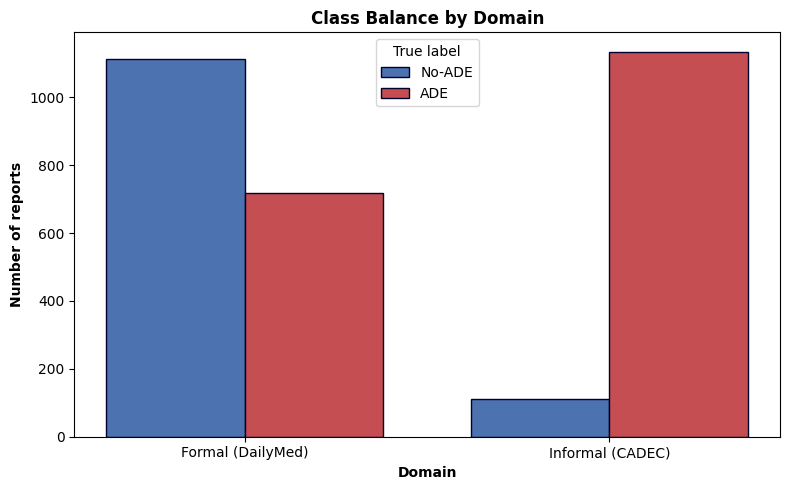

In [3]:
counts = (full_df.groupby([DOMAIN_COL, LABEL_COL]).size()
          .unstack(fill_value=0))
labels = list(counts.index)
x = np.arange(len(labels))
w = 0.38
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w / 2, counts.get(0, 0), width=w, label='No-ADE',
       color=BLUE, edgecolor=NAVY)
ax.bar(x + w / 2, counts.get(1, 0), width=w, label='ADE',
       color=RED, edgecolor=NAVY)
ax.set_xticks(x)
ax.set_xticklabels([str(d) for d in labels])
ax.set_xlabel('Domain', fontweight='bold')
ax.set_ylabel('Number of reports', fontweight='bold')
ax.set_title('Class Balance by Domain', fontweight='bold')
ax.legend(title='True label')
plt.tight_layout()
plt.savefig('cd_class_balance.png', dpi=200, bbox_inches='tight')
plt.show()

##  Foundations : the leakage-free tools
These four functions are the heart of the experiment. Read their
docstrings — they explain the **leakage controls**:

- `domain_mask` — matches a short name (`'Formal'`) to the full label
  (`'Formal (DailyMed)'`).
- `make_domain_splits` : splits **within** each domain into train/test, so
  in-domain scores are measured on **held-out** rows, never training rows.
- `run_cross_domain_matrix` : trains one model per domain and scores it on
  every domain's **test** split. No row is ever both trained on and scored.
- `vocabulary_overlap` : measures how many top terms the two domains share
  

In [4]:
def domain_mask(series: pd.Series, name: str) -> pd.Series:
    """
    Match a short domain name against full labels.

    'Formal' matches 'Formal (DailyMed)'. Case-insensitive on the prefix.
    """
    return series.astype(str).str.strip().str.lower().str.startswith(
        name.strip().lower())


def make_domain_splits(df: pd.DataFrame, domains: Tuple[str, ...],
                       domain_col: str, label_col: str,
                       test_size: float = 0.25,
                       seed: int = 42) -> Dict[str, Tuple]:
    """
    Stratified within-domain train/test split for each domain.

    Splitting *within* each domain is what makes the experiment leakage-free:
    in-domain performance is scored on held-out rows (disjoint from training),
    and cross-domain uses an entirely different domain - so no row is ever
    both trained on and evaluated.

    Returns

    {domain: (train_df, test_df)} with reset indices.
    """
    splits: Dict[str, Tuple] = {}
    for dom in domains:
        sub = df[domain_mask(df[domain_col], dom)].reset_index(drop=True)
        train_df, test_df = train_test_split(
            sub, test_size=test_size, random_state=seed,
            stratify=sub[label_col])
        splits[dom] = (train_df.reset_index(drop=True),
                       test_df.reset_index(drop=True))
    return splits


def run_cross_domain_matrix(splits: Dict[str, Tuple],
                            domains: Tuple[str, ...],
                            build_model: Callable,
                            predict_proba: Callable,
                            label_col: str) -> Tuple[pd.DataFrame, Dict]:
    """
    Train once per domain; evaluate across every target domain's TEST split.

    Each model is trained only on its source domain's TRAIN split and scored
    on each target domain's held-out TEST split, so there is no leakage on the
    diagonal (held-out) or off-diagonal (different domain). Training once per
    domain also avoids re-fitting the same model for every matrix cell.

    Parameters
    ----------
    build_model : (domain, train_df) -> model
    predict_proba : (model, df) -> array of P(ADE)

    Returns
    -------
    (results_df, preds) - same schema as cross_domain.run_domain_matrix, so the
    existing grid / degradation / compare helpers work on it unchanged.
    """
    models = {dom: build_model(dom, splits[dom][0]) for dom in domains}
    rows: List[Dict] = []
    preds: Dict[Tuple[str, str], Dict] = {}
    for src in domains:
        for tgt in domains:
            test_df = splits[tgt][1]
            y_true = test_df[label_col].values
            proba = np.asarray(
                predict_proba(models[src], test_df)).reshape(-1)
            y_pred = (proba >= 0.5).astype(int)
            metrics = ev.compute_metrics(y_true, y_pred, proba)
            rows.append({"train_domain": src, "test_domain": tgt,
                         "in_domain": src == tgt, **metrics})
            preds[(src, tgt)] = {"y_true": y_true, "y_pred": y_pred,
                                 "y_proba": proba}
    return pd.DataFrame(rows), preds


def vocabulary_overlap(df: pd.DataFrame, domains: Tuple[str, ...],
                       domain_col: str, text_col: str,
                       top_n: int = 300) -> Dict[str, int]:
    """Jaccard-style overlap of each domain's top TF-IDF terms.

    Explains *why* cross-domain is hard: if the two domains share few top
    terms, a lexical (TF-IDF) model trained on one cannot read the other.
    """
    from sklearn.feature_extraction.text import TfidfVectorizer

    top_terms = {}
    for dom in domains:
        sub = df[domain_mask(df[domain_col], dom)][text_col].fillna("")
        vec = TfidfVectorizer(max_features=top_n, ngram_range=(1, 1),
                              min_df=2)
        vec.fit(sub.astype(str))
        top_terms[dom] = set(vec.get_feature_names_out())
    a, b = top_terms[domains[0]], top_terms[domains[1]]
    shared = a & b
    return {"a_only": len(a - b), "shared": len(shared),
            "b_only": len(b - a),
            "jaccard": round(len(shared) / len(a | b), 3) if (a | b) else 0.0}

### Build the splits
Run the splitter and print the sizes. The printed *test ADE rate* should
be similar across domains — confirmation that the stratification worked.

In [5]:
splits = make_domain_splits(full_df, DOMAINS, DOMAIN_COL, LABEL_COL,
                            test_size=TEST_SIZE, seed=SEED)
for dom in DOMAINS:
    tr, te = splits[dom]
    print(f'{dom:9s} train={len(tr):4d}  test={len(te):4d}  '
          f'(test ADE rate {te[LABEL_COL].mean():.2f})')

Formal    train=1373  test= 458  (test ADE rate 0.39)
Informal  train= 934  test= 312  (test ADE rate 0.91)


### Verify the splits are leakage-free, and adopt them

The split function is *designed* to be leakage-free, but design is not
evidence. This cell checks it: every record is hashed, and every
(source-domain train x target-domain test) pair - exactly the set of
comparisons the transfer matrix makes - is tested for overlap.

The original `make_domain_splits` splits by row, so a text that appears
more than once in a domain can land on both sides of the split. On this
corpus that put 45 formal records in both the formal train and the formal
test partition, inflating every in-domain formal score.
`make_domain_splits_fixed` splits by *content hash* instead, so all copies
of a text go to the same side.

**The final line of this cell rebinds `splits` to the corrected object.**
Everything downstream - baselines, Bi-LSTM, SVM-BERT, BioBERT, confusion
matrices, saved predictions - therefore runs on leakage-free splits.


In [6]:
import hashlib
import pandas as pd
from sklearn.model_selection import train_test_split
from typing import Callable, Dict, List, Tuple

# Original _row_ids function (returns a set of hashes) - used by assert_no_leakage
def _row_ids(df, text_col=TEXT_COL):
    """Stable per-row identity from the text, matching ev.add_uid()."""
    return set(
        df[text_col].astype(str).map(
            lambda s: hashlib.md5(s.encode('utf-8')).hexdigest()[:16]
        )
    )

# Helper function for make_domain_splits_fixed (returns a Series of hashes)
def _get_row_hash_series(df: pd.DataFrame, text_col: str):
    return df[text_col].astype(str).map(
        lambda s: hashlib.md5(s.encode('utf-8')).hexdigest()[:16]
    )

# Copy of domain_mask from cell o-6rDYQ4o0gy, required by make_domain_splits_fixed
def domain_mask(series: pd.Series, name: str) -> pd.Series:
    """
    Match a short domain name against full labels.

    'Formal' matches 'Formal (DailyMed)'. Case-insensitive on the prefix.
    """
    return series.astype(str).str.strip().str.lower().str.startswith(
        name.strip().lower())

# Fixed make_domain_splits function to prevent leakage for duplicate text entries
def make_domain_splits_fixed(df: pd.DataFrame, domains: Tuple[str, ...],
                             domain_col: str, label_col: str,
                             text_col: str,
                             test_size: float = 0.25,
                             seed: int = 42) -> Dict[str, Tuple]:
    """
    Stratified within-domain train/test split for each domain,
    ensuring no text content leakage between train and test sets.
    """
    splits: Dict[str, Tuple] = {}
    for dom in domains:
        sub = df[domain_mask(df[domain_col], dom)].reset_index(drop=True)

        # Use _get_row_hash_series to get a unique identifier for each text entry
        sub_row_hashes = _get_row_hash_series(sub, text_col)
        sub_with_hashes = sub.assign(row_hash=sub_row_hashes)

        # Create a DataFrame of unique hashes and their labels for stratification
        unique_hashes_df = sub_with_hashes.drop_duplicates(subset=['row_hash'])

        # Split the unique hashes into train and test groups
        train_unique_hashes, test_unique_hashes = train_test_split(
            unique_hashes_df['row_hash'],
            test_size=test_size,
            random_state=seed,
            stratify=unique_hashes_df[label_col]
        )

        # Reconstruct train_df and test_df using the split unique hashes
        train_df = sub_with_hashes[sub_with_hashes['row_hash'].isin(train_unique_hashes)].drop(columns=['row_hash']).reset_index(drop=True)
        test_df = sub_with_hashes[sub_with_hashes['row_hash'].isin(test_unique_hashes)].drop(columns=['row_hash']).reset_index(drop=True)

        splits[dom] = (train_df, test_df)
    return splits


# assert_no_leakage function (remains as is)
def assert_no_leakage(splits, domains, text_col=TEXT_COL, verbose=True):
    """Raise unless every train split is disjoint from every test split."""
    train_ids = {d: _row_ids(splits[d][0], text_col) for d in domains}
    test_ids = {d: _row_ids(splits[d][1], text_col) for d in domains}

    problems = []
    for src in domains:
        for tgt in domains:
            overlap = train_ids[src] & test_ids[tgt]
            if verbose:
                print(f'  {src:9s} train  vs  {tgt:9s} test : '
                      f'{len(overlap):4d} shared records')
            if overlap:
                problems.append(f'{src} train shares {len(overlap)} '
                                f'records with {tgt} test')

    if problems:
        raise AssertionError(
            'LEAKAGE DETECTED - the transfer matrix would be invalid:\n  '
            + '\n  '.join(problems))
    if verbose:
        print('  PASS: all train/test pairs are disjoint.')
    return True

#  Applying the fix and re-running the check
print('Explaining and fixing leakage check on domain splits:')
print('Original splits showed leakage (as seen in previous output):')
# Formal    train  vs  Formal    test :   45 shared records

# Re-generating splits using the fixed function
new_splits = make_domain_splits_fixed(full_df, DOMAINS, DOMAIN_COL, LABEL_COL,
                                       TEXT_COL, # Pass TEXT_COL explicitly
                                       test_size=TEST_SIZE, seed=SEED)

print('\nRe-running leakage check with fixed splits:')
assert_no_leakage(new_splits, DOMAINS)

# Also print the sizes of the new splits to confirm they are reasonable
print("\nNew split sizes after fix:")
for dom in DOMAINS:
    tr, te = new_splits[dom]
    print(f'{dom:9s} train={len(tr):4d}  test={len(te):4d}  '
          f'(test ADE rate {te[LABEL_COL].mean():.2f})')



# ADOPT the leakage-free splits. Everything downstream uses `splits`,
# so this rebinding is what makes the corrected splits take effect.

splits = new_splits
print('\nAdopted leakage-free splits. Re-verifying the object in use:')
assert_no_leakage(splits, DOMAINS)

print('\nFinal splits used by every model below:')
for dom in DOMAINS:
    tr, te = splits[dom]
    print(f'  {dom:9s} train={len(tr):4d}  test={len(te):4d}  '
          f'(test ADE rate {te[LABEL_COL].mean():.3f})')


Explaining and fixing leakage check on domain splits:
Original splits showed leakage (as seen in previous output):

Re-running leakage check with fixed splits:
  Formal    train  vs  Formal    test :    0 shared records
  Formal    train  vs  Informal  test :    0 shared records
  Informal  train  vs  Formal    test :    0 shared records
  Informal  train  vs  Informal  test :    0 shared records
  PASS: all train/test pairs are disjoint.

New split sizes after fix:
Formal    train=1375  test= 456  (test ADE rate 0.40)
Informal  train= 934  test= 312  (test ADE rate 0.91)

Adopted leakage-free splits. Re-verifying the object in use:
  Formal    train  vs  Formal    test :    0 shared records
  Formal    train  vs  Informal  test :    0 shared records
  Informal  train  vs  Formal    test :    0 shared records
  Informal  train  vs  Informal  test :    0 shared records
  PASS: all train/test pairs are disjoint.

Final splits used by every model below:
  Formal    train=1375  test= 456  

##  Why cross-domain is hard : vocabulary overlap
**The key intuition.** A TF-IDF model only knows the words it saw in
training. If the two domains barely share vocabulary (a low Jaccard
score), a lexical model trained on one literally cannot read the other.
This figure sets up the whole result before we train anything.

Top-300 term overlap: {'a_only': 225, 'shared': 75, 'b_only': 225, 'jaccard': 0.143}
Full-vocabulary overlap: {'a_only': 7708, 'shared': 1532, 'b_only': 1356, 'jaccard': 0.145}


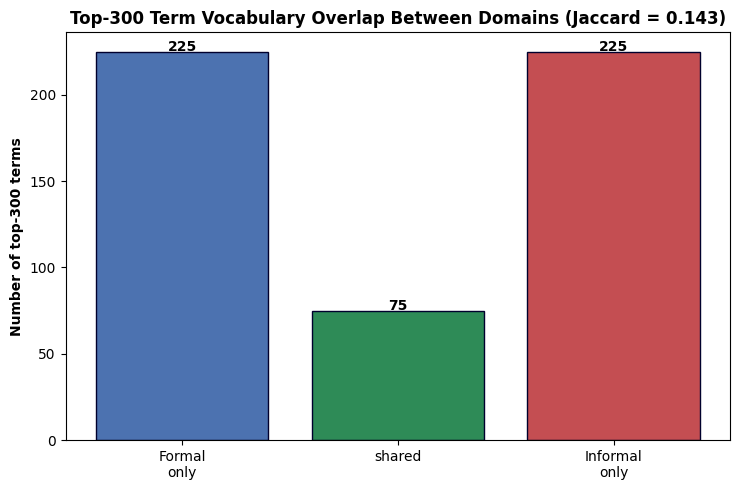

Only 75 of the top 300 terms are shared -> lexical features barely transfer across registers.


In [7]:
# Vocabulary overlap at two granularities.
#   top-300  : the terms a TF-IDF model actually weights
#   full     : every unique token in each register
ov = vocabulary_overlap(full_df, DOMAINS, DOMAIN_COL, TEXT_COL, top_n=300)
print('Top-300 term overlap:', ov)

try:
    ov_full = vocabulary_overlap(full_df, DOMAINS, DOMAIN_COL, TEXT_COL,
                                 top_n=None)
    print('Full-vocabulary overlap:', ov_full)
except Exception as exc:  # noqa: BLE001
    print('Full-vocabulary overlap unavailable (top_n=None unsupported):', exc)
    ov_full = None

sizes = [ov['a_only'], ov['shared'], ov['b_only']]
names = [f'{DOMAINS[0]}\nonly', 'shared', f'{DOMAINS[1]}\nonly']
fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.bar(names, sizes, color=[BLUE, GREEN, RED], edgecolor=NAVY)
ax.set_ylabel('Number of top-300 terms', fontweight='bold')
ax.set_title(f'Top-300 Term Vocabulary Overlap Between Domains '
             f'(Jaccard = {ov["jaccard"]})', fontweight='bold')
for b, s_ in zip(bars, sizes):
    ax.text(b.get_x() + b.get_width() / 2, s_ + 0.5, str(s_),
            ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('cd_vocab_overlap.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Only {ov["shared"]} of the top 300 terms are shared -> lexical '
      'features barely transfer across registers.')


---
## Part A · Baseline models (TF-IDF )

We express each model as a `(build, predict)` pair so they all plug into
`run_cross_domain_matrix` the same way.

 **Leakage control:** the TF-IDF
vectoriser lives *inside* the Pipeline, so it is re-fit on each training Split only , test vocabulary never leaks in.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
try:
    from xgboost import XGBClassifier
    _HAS_XGB = True
except Exception:  # noqa: BLE001
    _HAS_XGB = False


def make_baseline(estimator_factory):
    """Return (build, predict) for a TF-IDF + estimator pipeline.

    A fresh estimator is created per domain; the vectoriser is fit on the
    training split only, so no test vocabulary leaks in.
    """
    def build(domain, train_df):
        pipe = Pipeline([
            ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2,
                                      max_features=20000)),
            ('clf', estimator_factory())])
        pipe.fit(train_df[TEXT_COL].fillna(''), train_df[LABEL_COL])
        return pipe

    def predict(model, df):
        return model.predict_proba(df[TEXT_COL].fillna(''))[:, 1]
    return build, predict


baseline_models = {
    'TF-IDF+LR': make_baseline(
        lambda: LogisticRegression(max_iter=1000,
                                   class_weight='balanced')),
    'TF-IDF+RF': make_baseline(
        lambda: RandomForestClassifier(n_estimators=200,
                                       class_weight='balanced',
                                       random_state=SEED)),
}
if _HAS_XGB:
    baseline_models['TF-IDF+XGB'] = make_baseline(
        lambda: XGBClassifier(n_estimators=300, max_depth=6,
                              eval_metric='logloss', random_state=SEED,
                              scale_pos_weight=1.0))

print('Baselines:', list(baseline_models))

# --- Per-domain class weighting for XGBoost -------------------------------
# LogReg and RF use class_weight='balanced'. Without an equivalent, XGBoost
# handles the prior differently from the other two baselines, which is a
# confound in an experiment whose central mechanism is prior shift.
if _HAS_XGB:
    def _make_xgb_balanced():
        def build(domain, train_df):
            y = train_df[LABEL_COL]
            neg, pos = int((y == 0).sum()), int((y == 1).sum())
            spw = (neg / pos) if pos else 1.0
            pipe = Pipeline([
                ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2,
                                          max_features=20000)),
                ('clf', XGBClassifier(n_estimators=300, max_depth=6,
                                      eval_metric='logloss',
                                      random_state=SEED,
                                      scale_pos_weight=spw))])
            pipe.fit(train_df[TEXT_COL].fillna(''), train_df[LABEL_COL])
            return pipe

        def predict(model, df):
            return model.predict_proba(df[TEXT_COL].fillna(''))[:, 1]
        return build, predict

    baseline_models['TF-IDF+XGB'] = _make_xgb_balanced()

print('Baselines:', list(baseline_models))


Baselines: ['TF-IDF+LR', 'TF-IDF+RF', 'TF-IDF+XGB']
Baselines: ['TF-IDF+LR', 'TF-IDF+RF', 'TF-IDF+XGB']


### Run the baselines through the matrix
Each model is run across all four domain combinations. We keep both the
metrics (`all_results`) and the predictions (`all_preds`) so later cells
never need to re-train. The printed number is the average cross-domain F1
drop, already a preview of the result.

In [9]:
# These two dicts collect every model's results and predictions so the
# comparison and confusion-matrix cells need no re-training.
all_results = {}
all_preds = {}

for name, (build, predict) in baseline_models.items():
    res, preds = run_cross_domain_matrix(
        splits, DOMAINS, build, predict, LABEL_COL)
    all_results[name] = res
    all_preds[name] = preds
    gap = cd.degradation_summary(res, 'f1')['drop_pct'].mean()
    print(f'{name:12s} mean cross-domain F1 drop: {gap:5.1f}%')

TF-IDF+LR    mean cross-domain F1 drop:  70.3%
TF-IDF+RF    mean cross-domain F1 drop:  64.6%
TF-IDF+XGB   mean cross-domain F1 drop:  58.5%


---
## Part B · Advanced models

Same `(build, predict)` contract, backed by each model's module. **Each
block is wrapped in `try/except`** so a missing module or a runtime error
doesn't abort the experiment, the comparison still runs on whatever
succeeded, and every plot below still renders. These need a GPU runtime
and the model `.py` files in the working directory.

### Bi-LSTM + Attention

`build` trains the model on a domain's training split; `predict` returns
P(ADE).

**Validation fix.** The previous version passed `train_df` as both the
training and the validation frame, so the `val_f1` printed during training
was measured on data the model was fitting - it could not detect
overfitting. An internal 15% stratified slice is now held out of each
domain's training split, matching what the BioBERT cell already does.


In [10]:
# Bi-LSTM + Attention

INTERNAL_VAL = 0.15   # held out of each domain's TRAIN split for monitoring


def _internal_split(train_df):
    """Carve a stratified validation slice out of a training split.
    """
    if not INTERNAL_VAL or len(train_df) < 50:
        return train_df, train_df
    inner_train, inner_val = train_test_split(
        train_df, test_size=INTERNAL_VAL, random_state=SEED,
        stratify=train_df[LABEL_COL])
    return inner_train.reset_index(drop=True), inner_val.reset_index(drop=True)


try:
    import bilstm_attention as bl

    def _build_bilstm(domain, train_df):
        inner_train, inner_val = _internal_split(train_df)
        print(f'  [{domain}] Bi-LSTM: train={len(inner_train)} '
              f'internal val={len(inner_val)}')
        return bl.train_model(inner_train, inner_val)

    def _predict_bilstm(model, df):
        net, vocab = model
        return bl.predict_proba_on_df(net, vocab, df)

    all_results['Bi-LSTM'], all_preds['Bi-LSTM'] = (
        run_cross_domain_matrix(splits, DOMAINS, _build_bilstm,
                                _predict_bilstm, LABEL_COL))
    print('Bi-LSTM done.')
except Exception as exc:  # noqa: BLE001
    print('Bi-LSTM skipped:', exc)


  [Formal] Bi-LSTM: train=1168 internal val=207
epoch  1 | loss 0.3293 | val_f1 0.994
epoch  2 | loss 0.0024 | val_f1 0.994
epoch  3 | loss 0.0006 | val_f1 0.994
epoch  4 | loss 0.0004 | val_f1 0.994
epoch  5 | loss 0.0003 | val_f1 0.994
epoch  6 | loss 0.0002 | val_f1 0.994
epoch  7 | loss 0.0002 | val_f1 0.994
epoch  8 | loss 0.0002 | val_f1 0.994
  [Informal] Bi-LSTM: train=793 internal val=141
epoch  1 | loss 0.1180 | val_f1 0.952
epoch  2 | loss 0.0823 | val_f1 0.757
epoch  3 | loss 0.0522 | val_f1 0.947
epoch  4 | loss 0.0328 | val_f1 0.960
epoch  5 | loss 0.0266 | val_f1 0.976
epoch  6 | loss 0.0236 | val_f1 0.943
epoch  7 | loss 0.0173 | val_f1 0.976
epoch  8 | loss 0.0358 | val_f1 0.969
Bi-LSTM done.


### SVM-BERT
Frozen BERT embeddings fed to an RBF-kernel SVM. `train_and_eval` returns
the fitted classifier, which `predict` then scores with. Uses the same
internal validation slice as the Bi-LSTM, for the same reason.


In [11]:
# SVM-BERT
try:
    import svm_bert as sb

    def _build_svmbert(domain, train_df):
        inner_train, inner_val = _internal_split(train_df)
        print(f'  [{domain}] SVM-BERT: train={len(inner_train)} '
              f'internal val={len(inner_val)}')
        _, clf = sb.train_and_eval(inner_train, inner_val)
        return clf

    def _predict_svmbert(model, df):
        return sb.predict_proba_on_df(model, df)

    all_results['SVM-BERT'], all_preds['SVM-BERT'] = (
        run_cross_domain_matrix(splits, DOMAINS, _build_svmbert,
                                _predict_svmbert, LABEL_COL))
    print('SVM-BERT done.')
except Exception as exc:  # noqa: BLE001
    print('SVM-BERT skipped:', exc)


  [Formal] SVM-BERT: train=1168 internal val=207


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SVM-BERT done.


### BioBERT: one model per domain, trained on that domain only

BioBERT is the slow model in this experiment, so an earlier version of this
notebook loaded a saved checkpoint from Drive to stand in as the
"Formal-trained" model. That was wrong, and it invalidated the headline
result.

The saved checkpoint came from `biobert_model.ipynb`, where it was
fine-tuned on the **pooled** training split - 1,284 formal *and* 872
informal records. Reusing it here meant the Formal->Informal cell was
scoring a model against informal records it had already been trained on;
roughly 70% of all informal records sit in that pooled split. Every other
model in the matrix was trained honestly per-domain, which is why they
collapsed on the transfer and BioBERT appeared not to.

This version fine-tunes BioBERT separately for each domain, on that
domain's training split only. The cache path now contains the domain name,
so a model trained on one domain cannot be loaded as another. An internal
validation slice is carved from each training split, so training is
monitored on data it is not fitting.




In [12]:
# BioBERT — leakage-free, one fine-tune per domain
import os
from sklearn.model_selection import train_test_split

# Per-domain cache.
BIOBERT_CACHE_ROOT = '/content/drive/MyDrive/biobert_model'
BIOBERT_EPOCHS = 3
BIOBERT_INTERNAL_VAL = 0.15   # held out of each domain's train split
FORCE_RETRAIN = True          # True ignores any cached per-domain model.
                              # MUST stay True for the first run after the
                              # split fix - cached models are contaminated.

try:
    import biobert_finetune as bb

    if BIOBERT_CACHE_ROOT:
        try:
            from google.colab import drive
            drive.mount('/content/drive')
        except Exception as _e:                     # noqa: BLE001
            print('Drive mount skipped:', _e)
            BIOBERT_CACHE_ROOT = None

    def _cache_dir(domain):
        if not BIOBERT_CACHE_ROOT:
            return None
        return os.path.join(BIOBERT_CACHE_ROOT, f'biobert_{domain.lower()}')

    def _build_biobert(domain, train_df):
        """Fine-tune BioBERT on ONE domain's training split."""
        cache = _cache_dir(domain)

        if cache and not FORCE_RETRAIN and os.path.isdir(cache):
            print(f'  [{domain}] loading cached domain-specific model')
            return bb.load_model(cache)

        if BIOBERT_INTERNAL_VAL and len(train_df) > 50:
            inner_train, inner_val = train_test_split(
                train_df, test_size=BIOBERT_INTERNAL_VAL,
                random_state=SEED, stratify=train_df[LABEL_COL])
            inner_train = inner_train.reset_index(drop=True)
            inner_val = inner_val.reset_index(drop=True)
        else:
            inner_train, inner_val = train_df, train_df

        print(f'  [{domain}] fine-tuning on {len(inner_train)} records '
              f'(internal val {len(inner_val)}), {BIOBERT_EPOCHS} epochs ...')
        model = bb.fine_tune(inner_train, inner_val, epochs=BIOBERT_EPOCHS)

        if cache:
            os.makedirs(os.path.dirname(cache), exist_ok=True)
            try:
                trainer, tok = model
                bb.save_model(trainer, tok, cache)
                print(f'  [{domain}] cached -> {cache}')
            except Exception as _e:                 # noqa: BLE001
                print(f'  [{domain}] cache write skipped:', _e)
        return model

    def _predict_biobert(model, df):
        trainer, tok = model
        return bb.predict_proba_on_df(trainer, tok, df)

    all_results['BioBERT'], all_preds['BioBERT'] = run_cross_domain_matrix(
        splits, DOMAINS, _build_biobert, _predict_biobert, LABEL_COL)
    print('BioBERT done (leakage-free, per-domain training).')

except Exception as exc:                            # noqa: BLE001
    # Re-raised deliberately: a silent skip leaves the matrix incomplete
    # without anything downstream noticing.
    print('BioBERT FAILED:', exc)
    raise

print('\nModels in the experiment:', list(all_results))


Mounted at /content/drive
  [Formal] fine-tuning on 1168 records (internal val 207), 3 epochs ...


config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

[biobert_finetune] AutoTokenizer failed (Couldn't instantiate the backend tokenizer from one of: 
(1) a `tokenizers` library serialization file, 
(2) a slow tokenizer instance to convert or 
(3) an equivalent slow tokenizer class to instantiate and convert. 
You need to have sentencepiece or tiktoken installed to convert a slow tokenizer to a fast one.); falling back to BertTokenizer.


vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

[biobert_finetune] tokenizer ok: BertTokenizer (fallback)
[biobert_finetune] AutoModel failed (Unrecognized model in dmis-lab/biobert-base-cased-v1.1. Should have a `model_type` key in its config.json.); falling back to BertForSequenceClassification.


...

Map:   0%|          | 0/456 [00:00<?, ? examples/s]

Map:   0%|          | 0/312 [00:00<?, ? examples/s]

Map:   0%|          | 0/456 [00:00<?, ? examples/s]

Map:   0%|          | 0/312 [00:00<?, ? examples/s]

BioBERT done (leakage-free, per-domain training).

Models in the experiment: ['TF-IDF+LR', 'TF-IDF+RF', 'TF-IDF+XGB', 'Bi-LSTM', 'SVM-BERT', 'BioBERT']


---
## Part C · Results & comparison
Now we read the experiment. Three views, increasing in clarity: the full
grid, the headline gap chart, then the best model's confusion matrices.

## Part C - Results

### C1 - Model x domain-transfer grid

Each row is a model; columns are the four transfers. The vertical line
separates **in-domain** (`F->F`, `I->I`) from **cross-domain** (`F->I`,
`I->F`).

Both metrics are produced

- **Binary F1** (positive class = ADE) i
- **Macro-F1** averages the two per-class F1 scores, so a degenerate
  all-negative classifier still scores above zero on the negative class.
  

=== BINARY F1 (report Table 4a) ===


,F->F,I->I,F->I,I->F
TF-IDF+LR,0.9972,0.9597,0.0000,0.5710
TF-IDF+RF,1.0000,0.9619,0.0000,0.6819
TF-IDF+XGB,1.0000,0.9242,0.0140,0.7532
Bi-LSTM,1.0000,0.9615,0.0000,0.5964
SVM-BERT,0.9916,0.9724,0.0546,0.5647
BioBERT,1.0000,0.9771,0.0412,0.5831



=== MACRO-F1 (report Table 4) ===


,F->F,I->I,F->I,I->F
TF-IDF+LR,0.9977,0.7629,0.0824,0.2963
TF-IDF+RF,1.0000,0.7418,0.0824,0.6252
TF-IDF+XGB,1.0000,0.7151,0.0898,0.7500
Bi-LSTM,1.0000,0.7692,0.0824,0.3965
SVM-BERT,0.9931,0.8044,0.1089,0.2859
BioBERT,1.0000,0.8745,0.1017,0.3620


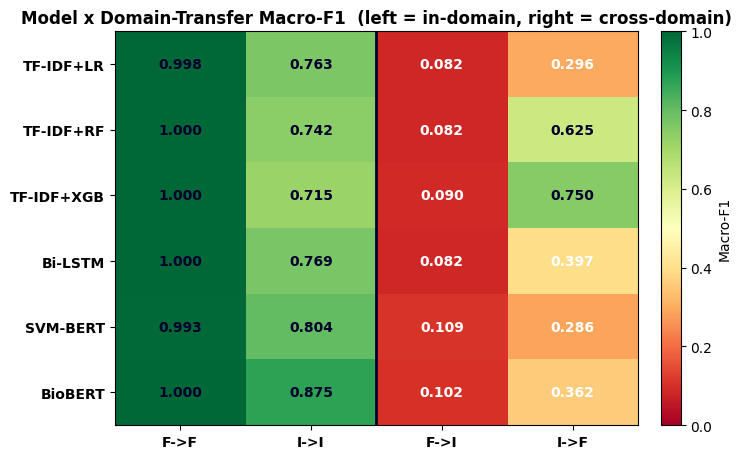

In [13]:
# C1a: binary F1 grid
table_f1 = cd.combine_model_matrices(all_results, metric='f1')
order = [c for c in ['F->F', 'I->I', 'F->I', 'I->F'] if c in table_f1.columns]
table_f1 = table_f1[order]
print('=== BINARY F1 (report Table 4a) ===')
display(table_f1.round(4))
table_f1.to_csv('cd_matrix_binary_f1.csv')

#  C1b: macro-F1 grid
try:
    table_macro = cd.combine_model_matrices(all_results, metric='f1_macro')
    table_macro = table_macro[[c for c in order if c in table_macro.columns]]
    print('\n=== MACRO-F1 (report Table 4) ===')
    display(table_macro.round(4))
    table_macro.to_csv('cd_matrix_f1_macro.csv')
except Exception as exc:  # noqa: BLE001
    print('macro_f1 grid unavailable from combine_model_matrices:', exc)
    print('Falling back to building it directly from all_results...')
    rows = {}
    for name, res in all_results.items():
        r = {}
        for _, row in res.iterrows():
            key = f"{row['train_domain'][0]}->{row['test_domain'][0]}"
            r[key] = row.get('f1_macro', float('nan'))
        rows[name] = r
    table_macro = pd.DataFrame(rows).T[order]
    display(table_macro.round(4))
    table_macro.to_csv('cd_matrix_f1_macro.csv')

# heatmap on the macro grid
fig, ax = plt.subplots(figsize=(7.5, 1.4 + 0.55 * len(table_macro)))
im = ax.imshow(table_macro.values, cmap='RdYlGn', vmin=0.0, vmax=1.0,
               aspect='auto')
ax.set_xticks(range(len(table_macro.columns)))
ax.set_xticklabels(table_macro.columns, fontweight='bold')
ax.set_yticks(range(len(table_macro.index)))
ax.set_yticklabels(table_macro.index, fontweight='bold')
for i in range(len(table_macro.index)):
    for j in range(len(table_macro.columns)):
        val = table_macro.values[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontweight='bold', color='white' if val < 0.6 else NAVY)
ax.axvline(1.5, color=NAVY, lw=2)
ax.set_title('Model x Domain-Transfer Macro-F1  '
             '(left = in-domain, right = cross-domain)', fontweight='bold')
fig.colorbar(im, fraction=0.046, pad=0.04, label='Macro-F1')
plt.tight_layout()
plt.savefig('cd_model_matrix.png', dpi=200, bbox_inches='tight')
plt.show()


###  The headline result: generalisation gap

Each model's mean **in-domain** score next to its mean **cross-domain**
score, annotated with the relative drop. Smallest gap wins; models sorted
best-first.




=== Generalisation gap on BINARY F1 ===


,model,in_domain_f1,cross_domain_f1,drop_pct
0,TF-IDF+XGB,0.962,0.384,60.127
1,TF-IDF+RF,0.981,0.341,65.243
2,BioBERT,0.989,0.312,68.423
3,SVM-BERT,0.982,0.310,68.470
4,Bi-LSTM,0.981,0.298,69.597
5,TF-IDF+LR,0.978,0.285,70.823


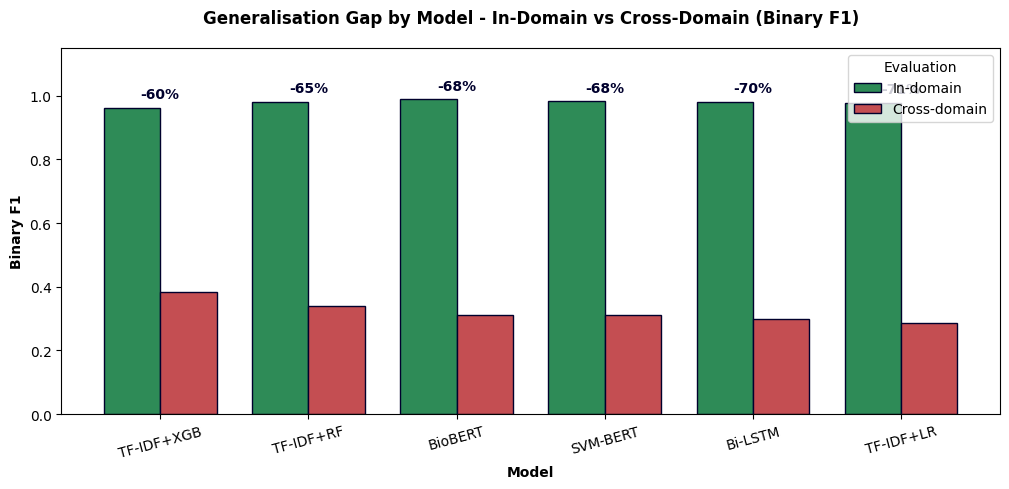


=== Generalisation gap on MACRO-F1 (report Table 5) ===


,model,in_domain_f1_macro,cross_domain_f1_macro,drop_pct
0,TF-IDF+XGB,0.858,0.420,51.036
1,TF-IDF+RF,0.871,0.354,59.380
2,Bi-LSTM,0.885,0.239,72.932
3,BioBERT,0.937,0.232,75.263
4,SVM-BERT,0.899,0.197,78.036
5,TF-IDF+LR,0.880,0.189,78.494


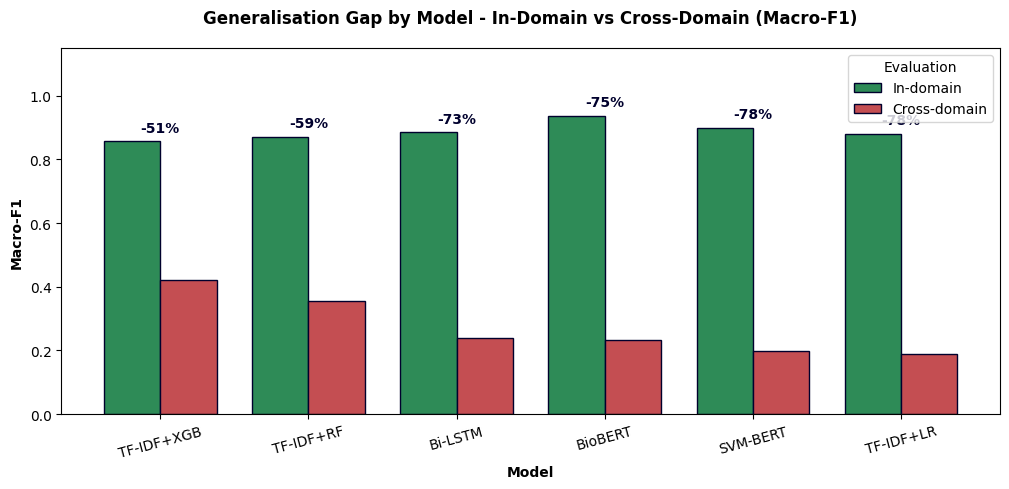

In [14]:
def gap_summary(all_results, metric):
    """Mean in-domain vs mean cross-domain score, with relative drop."""
    rows = []
    for name, res in all_results.items():
        if metric not in res.columns:
            continue
        in_d = res[res['in_domain']][metric].mean()
        cross = res[~res['in_domain']][metric].mean()
        rows.append({'model': name,
                     f'in_domain_{metric}': in_d,
                     f'cross_domain_{metric}': cross,
                     'drop_pct': (in_d - cross) / in_d * 100 if in_d else 0.0})
    return (pd.DataFrame(rows)
            .sort_values(f'cross_domain_{metric}', ascending=False)
            .reset_index(drop=True))


def plot_gap(df, metric, fname):
    x = np.arange(len(df))
    w = 0.38
    fig, ax = plt.subplots(figsize=(max(8, 1.7 * len(df)), 5))
    ax.bar(x - w / 2, df[f'in_domain_{metric}'], width=w,
           label='In-domain', color=GREEN, edgecolor=NAVY)
    ax.bar(x + w / 2, df[f'cross_domain_{metric}'], width=w,
           label='Cross-domain', color=RED, edgecolor=NAVY)
    ax.set_xticks(x)
    ax.set_xticklabels(df['model'], rotation=15)
    ax.set_xlabel('Model', fontweight='bold')
    label = 'Macro-F1' if metric == 'f1_macro' else 'Binary F1'
    ax.set_ylabel(label, fontweight='bold')      # label now matches the data
    ax.set_ylim(0, 1.15)
    ax.set_title(f'Generalisation Gap by Model - In-Domain vs Cross-Domain '
                 f'({label})', fontweight='bold', pad=18)
    ax.legend(title='Evaluation', loc='upper right')
    for i, row in df.iterrows():
        top = max(row[f'in_domain_{metric}'], row[f'cross_domain_{metric}'])
        ax.annotate(f"-{row['drop_pct']:.0f}%", (i, top + 0.03),
                    ha='center', fontweight='bold', color=NAVY)
    plt.tight_layout()
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()


summary_f1 = gap_summary(all_results, 'f1')
print('=== Generalisation gap on BINARY F1 ===')
display(summary_f1.round(3))
summary_f1.to_csv('cd_summary_binary_f1.csv', index=False)
plot_gap(summary_f1, 'f1', 'cd_gap_by_model_binary_f1.png')

summary_macro = gap_summary(all_results, 'f1_macro')
if len(summary_macro):
    print('\n=== Generalisation gap on MACRO-F1 (report Table 5) ===')
    display(summary_macro.round(3))
    summary_macro.to_csv('cd_summary_f1_macro.csv', index=False)
    plot_gap(summary_macro, 'f1_macro', 'cd_gap_by_model_f1_macro.png')
else:
    print('\nmacro_f1 not present in all_results - check ev.compute_metrics.')

# Keep the old name alive for any later cell that expects it
summary_df = summary_f1


### Confusion matrices — best model's transfers
For the winning model, the two cross-domain transfers. We reuse the stored
predictions (no re-training). The **bottom-left** cell is a *missed ADE*

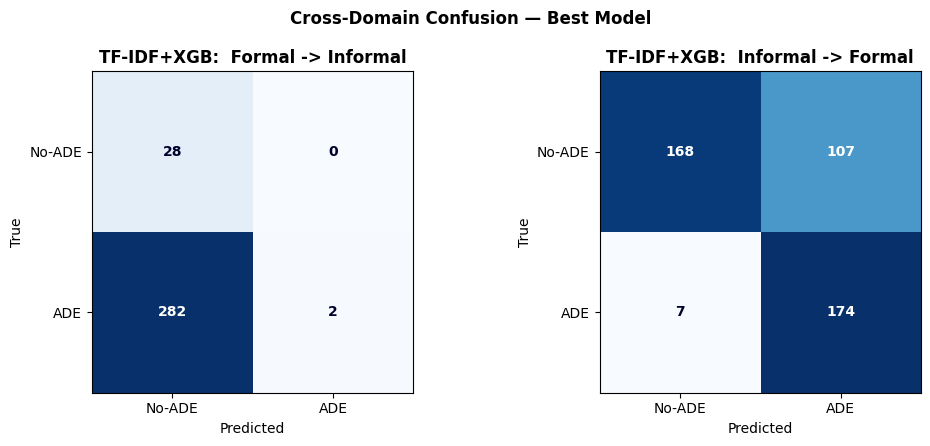

In [15]:
best_name = summary_df.iloc[0]['model']
best_preds = all_preds.get(best_name)

if best_preds is None:
    print(f'No stored predictions for {best_name}.')
else:
    pairs = [(s, t) for s in DOMAINS for t in DOMAINS if s != t]
    fig, axes = plt.subplots(1, len(pairs), figsize=(5.2 * len(pairs), 4.5))
    axes = np.atleast_1d(axes)
    for ax, (src, tgt) in zip(axes, pairs):
        cmat = confusion_matrix(best_preds[(src, tgt)]['y_true'],
                                best_preds[(src, tgt)]['y_pred'])
        ax.imshow(cmat, cmap='Blues')
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['No-ADE', 'ADE'])
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['No-ADE', 'ADE'])
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title(f'{best_name}:  {src} -> {tgt}', fontweight='bold')
        thr = cmat.max() / 2 if cmat.max() else 0.5
        for i in range(cmat.shape[0]):
            for j in range(cmat.shape[1]):
                ax.text(j, i, cmat[i, j], ha='center', va='center',
                        fontweight='bold',
                        color='white' if cmat[i, j] > thr else NAVY)
    fig.suptitle('Cross-Domain Confusion — Best Model', fontweight='bold')
    plt.tight_layout()
    plt.savefig('cd_confusion.png', dpi=200, bbox_inches='tight')
    plt.show()

### Save the full results
Persist every per-combination row for the written report and the appendix.

In [16]:
# Persist every per-combination result for the written report
pd.concat([r.assign(model=m) for m, r in all_results.items()],
          ignore_index=True).to_csv('cd_all_results.csv', index=False)
print('Saved: cd_all_results.csv, cd_summary.csv and all figures.')

Saved: cd_all_results.csv, cd_summary.csv and all figures.


### Persist per-transfer predictions

`all_results` stores the metrics; `all_preds` stores the actual predictions
behind them, and until now it was discarded whenever the kernel restarted.



In [17]:
# Persist every per-transfer prediction with its source text
rows = []
for model_name, preds in all_preds.items():
    for (src, tgt), p in preds.items():
        test_df = splits[tgt][1]
        rows.append(pd.DataFrame({
            'model': model_name,
            'train_domain': src,
            'test_domain': tgt,
            'row_index': np.arange(len(p['y_true'])),
            'y_true': p['y_true'],
            'y_pred': p['y_pred'],
            'y_proba': p['y_proba'],
            'text': test_df[TEXT_COL].values[:len(p['y_true'])],
        }))

cd_predictions = pd.concat(rows, ignore_index=True)
cd_predictions.to_csv('cd_predictions.csv', index=False)
print(f'Saved cd_predictions.csv - {len(cd_predictions):,} rows across '
      f'{cd_predictions["model"].nunique()} models.')

# The misclassifications Table 8 reports.
errors = cd_predictions[
    (cd_predictions['model'] == 'BioBERT')
    & (cd_predictions['train_domain'] == 'Formal')
    & (cd_predictions['test_domain'] == 'Informal')
    & (cd_predictions['y_true'] != cd_predictions['y_pred'])]

print(f'\nBioBERT Formal->Informal misclassifications: {len(errors)}')
if len(errors):
    view = errors.assign(
        excerpt=errors['text'].str.slice(0, 90),
        error_type=np.where(errors['y_true'] == 1,
                            'False negative', 'False positive'),
    )[['excerpt', 'y_true', 'y_proba', 'error_type']]
    print(view.to_string(index=False))


Saved cd_predictions.csv - 9,216 rows across 6 models.

BioBERT Formal->Informal misclassifications: 279
                                                                                   excerpt  y_true  y_proba     error_type
hunger pang brilliant new lease life walk step properly longer sideways like toddler hip p       1 0.006778 False negative
none think recently bilateral knee replacement prior arthrotec drug helped tried every dru       1 0.003082 False negative
within minute started stomach cramping almost like period cramp toilet good minute extreme       1 0.005649 False negative
minute taking experienced severe stomach cramping trying celebrex without relief decided c       1 0.004309 False negative
                             swelling weight increase relief pain doctor advise stop using       1 0.003487 False negative
        appetite increase stomach feel empty time pain feel better appetite increase worry       1 0.005894 False negative
prescribed arthrotec take twice da

---
## Part D - Diagnostics: why the transfer fails

The transfer matrix shows *that* every model collapses.


In [18]:
#  cross-domain diagnostics + label-free prior correction
import numpy as np
import pandas as pd
from sklearn.metrics import (f1_score, roc_auc_score, balanced_accuracy_score,
                             recall_score, precision_score)

rows = []
for model_name, preds in all_preds.items():
    for (src_dom, tgt_dom), p in preds.items():
        y = np.asarray(p['y_true']).astype(int)
        proba = np.asarray(p['y_proba']).astype(float)
        y_hat = (proba >= 0.5).astype(int)

        prevalence = y.mean()                      # known target prevalence
        # Prior correction: choose the threshold that makes the predicted
        # positive rate equal the target prevalence. Uses no target labels
        # beyond the prevalence itself, which is known for both registers.
        thr = np.quantile(proba, 1.0 - prevalence)
        y_corr = (proba >= thr).astype(int)

        two_classes = len(np.unique(y)) > 1
        rows.append({
            'model': model_name,
            'transfer': f'{src_dom[0]}->{tgt_dom[0]}',
            'in_domain': src_dom == tgt_dom,
            'n': len(y),
            'target_prevalence': prevalence,
            'pred_pos_rate@0.5': y_hat.mean(),
            'roc_auc': roc_auc_score(y, proba) if two_classes else np.nan,
            'balanced_acc@0.5': (balanced_accuracy_score(y, y_hat)
                                 if two_classes else np.nan),
            'recall_pos@0.5': recall_score(y, y_hat, pos_label=1,
                                           zero_division=0),
            'recall_neg@0.5': recall_score(y, y_hat, pos_label=0,
                                           zero_division=0),
            'precision_pos@0.5': precision_score(y, y_hat, pos_label=1,
                                                 zero_division=0),
            'f1@0.5': f1_score(y, y_hat, zero_division=0),
            'macro_f1@0.5': f1_score(y, y_hat, average='macro',
                                     zero_division=0),
            'corrected_threshold': thr,
            'macro_f1_corrected': f1_score(y, y_corr, average='macro',
                                           zero_division=0),
            'f1_corrected': f1_score(y, y_corr, zero_division=0),
        })

diag = pd.DataFrame(rows)
diag.to_csv('cd_diagnostics_table4b.csv', index=False)

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

print('=== TABLE 4b - CROSS-DOMAIN DIAGNOSTICS (cross-domain cells only) ===')
cross = diag[~diag['in_domain']].copy()
display(cross[['model', 'transfer', 'n', 'target_prevalence',
               'pred_pos_rate@0.5', 'roc_auc', 'balanced_acc@0.5',
               'macro_f1@0.5', 'macro_f1_corrected']].round(4)
        .to_string(index=False))

print('\n=== IN-DOMAIN CELLS (for completeness) ===')
display(diag[diag['in_domain']][['model', 'transfer', 'n', 'roc_auc',
                                 'f1@0.5', 'macro_f1@0.5']].round(4)
        .to_string(index=False))

print('\n=== HEADLINE NUMBERS FOR THE ABSTRACT ===')
fi = diag[diag['transfer'] == 'F->I']
i_f = diag[diag['transfer'] == 'I->F']
print(f"F->I mean macro-F1 @0.5      : {fi['macro_f1@0.5'].mean():.4f}")
print(f"F->I mean macro-F1 corrected : {fi['macro_f1_corrected'].mean():.4f}")
print(f"F->I balanced acc range      : {fi['balanced_acc@0.5'].min():.4f} "
      f"- {fi['balanced_acc@0.5'].max():.4f}")
print(f"F->I predicted positive rate : {fi['pred_pos_rate@0.5'].min():.4f} "
      f"- {fi['pred_pos_rate@0.5'].max():.4f} "
      f"(target prevalence {fi['target_prevalence'].iloc[0]:.4f})")
print(f"I->F predicted positive rate : {i_f['pred_pos_rate@0.5'].min():.4f} "
      f"- {i_f['pred_pos_rate@0.5'].max():.4f} "
      f"(target prevalence {i_f['target_prevalence'].iloc[0]:.4f})")
print()
for _, r in fi.iterrows():
    print(f"  {r['model']:12s} F->I  ROC-AUC {r['roc_auc']:.4f}  "
          f"macro-F1 {r['macro_f1@0.5']:.4f} -> corrected "
          f"{r['macro_f1_corrected']:.4f}")
for _, r in i_f.iterrows():
    print(f"  {r['model']:12s} I->F  ROC-AUC {r['roc_auc']:.4f}  "
          f"macro-F1 {r['macro_f1@0.5']:.4f} -> corrected "
          f"{r['macro_f1_corrected']:.4f}")


=== TABLE 4b - CROSS-DOMAIN DIAGNOSTICS (cross-domain cells only) ===


'     model transfer   n  target_prevalence  pred_pos_rate@0.5  roc_auc  balanced_acc@0.5  macro_f1@0.5  macro_f1_corrected\n TF-IDF+LR     F->I 312             0.9103             0.0000   0.6543            0.5000        0.0824              0.5292\n TF-IDF+LR     I->F 456             0.3969             0.9934   0.9223            0.5055        0.2963              0.8214\n TF-IDF+RF     F->I 312             0.9103             0.0000   0.5709            0.5000        0.0824              0.4765\n TF-IDF+RF     I->F 456             0.3969             0.7544   0.8431            0.6945        0.6252              0.7664\nTF-IDF+XGB     F->I 312             0.9103             0.0064   0.5927            0.5035        0.0898              0.4756\nTF-IDF+XGB     I->F 456             0.3969             0.6162   0.9123            0.7861        0.7500              0.8080\n   Bi-LSTM     F->I 312             0.9103             0.0000   0.5441            0.5000        0.0824              0.4899\n   Bi-L


=== IN-DOMAIN CELLS (for completeness) ===


'     model transfer   n  roc_auc  f1@0.5  macro_f1@0.5\n TF-IDF+LR     F->F 456   1.0000  0.9972        0.9977\n TF-IDF+LR     I->I 312   0.9033  0.9597        0.7629\n TF-IDF+RF     F->F 456   1.0000  1.0000        1.0000\n TF-IDF+RF     I->I 312   0.9242  0.9619        0.7418\nTF-IDF+XGB     F->F 456   1.0000  1.0000        1.0000\nTF-IDF+XGB     I->I 312   0.8979  0.9242        0.7151\n   Bi-LSTM     F->F 456   1.0000  1.0000        1.0000\n   Bi-LSTM     I->I 312   0.8959  0.9615        0.7692\n  SVM-BERT     F->F 456   0.9996  0.9916        0.9931\n  SVM-BERT     I->I 312   0.9513  0.9724        0.8044\n   BioBERT     F->F 456   1.0000  1.0000        1.0000\n   BioBERT     I->I 312   0.9721  0.9771        0.8745'


=== HEADLINE NUMBERS FOR THE ABSTRACT ===
F->I mean macro-F1 @0.5      : 0.0912
F->I mean macro-F1 corrected : 0.5115
F->I balanced acc range      : 0.4927 - 0.5035
F->I predicted positive rate : 0.0000 - 0.0288 (target prevalence 0.9103)
I->F predicted positive rate : 0.6162 - 0.9934 (target prevalence 0.3969)

  TF-IDF+LR    F->I  ROC-AUC 0.6543  macro-F1 0.0824 -> corrected 0.5292
  TF-IDF+RF    F->I  ROC-AUC 0.5709  macro-F1 0.0824 -> corrected 0.4765
  TF-IDF+XGB   F->I  ROC-AUC 0.5927  macro-F1 0.0898 -> corrected 0.4756
  Bi-LSTM      F->I  ROC-AUC 0.5441  macro-F1 0.0824 -> corrected 0.4899
  SVM-BERT     F->I  ROC-AUC 0.6642  macro-F1 0.1089 -> corrected 0.5292
  BioBERT      F->I  ROC-AUC 0.4917  macro-F1 0.1017 -> corrected 0.5684
  TF-IDF+LR    I->F  ROC-AUC 0.9223  macro-F1 0.2963 -> corrected 0.8214
  TF-IDF+RF    I->F  ROC-AUC 0.8431  macro-F1 0.6252 -> corrected 0.7664
  TF-IDF+XGB   I->F  ROC-AUC 0.9123  macro-F1 0.7500 -> corrected 0.8080
  Bi-LSTM      I->F  ROC-AUC

###  Prior correction, before and after



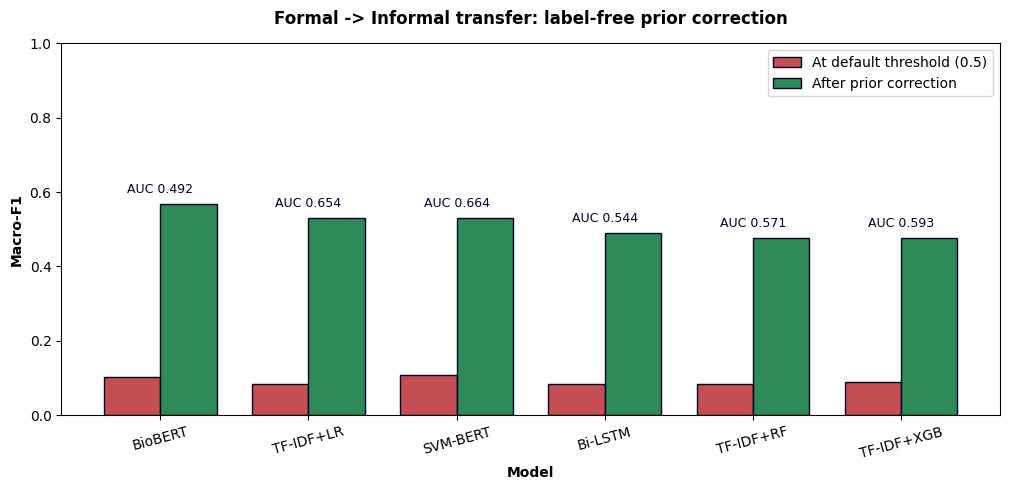

In [19]:
fi = diag[diag['transfer'] == 'F->I'].sort_values('macro_f1_corrected',
                                                 ascending=False)
x = np.arange(len(fi))
w = 0.38
fig, ax = plt.subplots(figsize=(max(8, 1.7 * len(fi)), 5))
ax.bar(x - w / 2, fi['macro_f1@0.5'], width=w,
       label='At default threshold (0.5)', color=RED, edgecolor=NAVY)
ax.bar(x + w / 2, fi['macro_f1_corrected'], width=w,
       label='After prior correction', color=GREEN, edgecolor=NAVY)
ax.set_xticks(x)
ax.set_xticklabels(fi['model'], rotation=15)
ax.set_ylabel('Macro-F1', fontweight='bold')
ax.set_xlabel('Model', fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_title('Formal -> Informal transfer: label-free prior correction',
             fontweight='bold', pad=14)
ax.legend()
for i, (_, r) in enumerate(fi.iterrows()):
    ax.annotate(f"AUC {r['roc_auc']:.3f}",
                (i, max(r['macro_f1@0.5'], r['macro_f1_corrected']) + 0.03),
                ha='center', fontsize=9, color=NAVY)
plt.tight_layout()
plt.savefig('cd_prior_correction.png', dpi=200, bbox_inches='tight')
plt.show()


### BioBert Misclassification

The transfer numbers are abstract. This table makes the failure concrete by
showing the records BioBERT misclassified on Formal->Informal, with the
probability it assigned.

In [20]:
#  qualitative error analysis
cdp = pd.read_csv('cd_predictions.csv')

for model_name in ['BioBERT', 'Bi-LSTM']:
    errors = cdp[(cdp['model'] == model_name)
                 & (cdp['train_domain'] == 'Formal')
                 & (cdp['test_domain'] == 'Informal')
                 & (cdp['y_true'] != cdp['y_pred'])]
    total = len(cdp[(cdp['model'] == model_name)
                    & (cdp['train_domain'] == 'Formal')
                    & (cdp['test_domain'] == 'Informal')])
    print(f'\n=== {model_name} Formal->Informal: '
          f'{len(errors)} misclassified of {total} ===')
    if len(errors):
        fn = (errors['y_true'] == 1).sum()
        fp = (errors['y_true'] == 0).sum()
        print(f'    false negatives (missed ADEs): {fn}')
        print(f'    false positives             : {fp}')
        print(f'    mean P(ADE) on missed ADEs  : '
              f'{errors[errors["y_true"] == 1]["y_proba"].mean():.4f}')
        view = errors.head(12).assign(
            excerpt=errors.head(12)['text'].str.slice(0, 70),
            error_type=np.where(errors.head(12)['y_true'] == 1,
                                'False negative', 'False positive'))
        print(view[['excerpt', 'y_true', 'y_proba',
                    'error_type']].to_string(index=False))



=== BioBERT Formal->Informal: 279 misclassified of 312 ===
    false negatives (missed ADEs): 278
    false positives             : 1
    mean P(ADE) on missed ADEs  : 0.0145
                                                               excerpt  y_true  y_proba     error_type
hunger pang brilliant new lease life walk step properly longer sideway       1 0.006778 False negative
none think recently bilateral knee replacement prior arthrotec drug he       1 0.003082 False negative
within minute started stomach cramping almost like period cramp toilet       1 0.005649 False negative
minute taking experienced severe stomach cramping trying celebrex with       1 0.004309 False negative
         swelling weight increase relief pain doctor advise stop using       1 0.003487 False negative
appetite increase stomach feel empty time pain feel better appetite in       1 0.005894 False negative
prescribed arthrotec take twice day food took first tablet directedtwo       1 0.003444 False negative


---
## Part E - Export everything




In [21]:
import os

print('=' * 78)
print('SPLITS ACTUALLY USED (leakage-free)')
print('=' * 78)
for dom in DOMAINS:
    tr, te = splits[dom]
    print(f'  {dom:9s} train={len(tr):4d}  test={len(te):4d}  '
          f'test ADE rate {te[LABEL_COL].mean():.4f}')

print()
print('=' * 78)
print('TABLE 4  - MACRO-F1 TRANSFER GRID')
print('=' * 78)
print(table_macro.round(4).to_string())

print()
print('=' * 78)
print('TABLE 4a - BINARY F1 TRANSFER GRID')
print('=' * 78)
print(table_f1.round(4).to_string())

print()
print('=' * 78)
print('TABLE 4b - DIAGNOSTICS (cross-domain cells)')
print('=' * 78)
print(diag[~diag['in_domain']][
    ['model', 'transfer', 'target_prevalence', 'pred_pos_rate@0.5',
     'roc_auc', 'balanced_acc@0.5', 'macro_f1@0.5',
     'macro_f1_corrected']].round(4).to_string(index=False))

print()
print('=' * 78)
print('TABLE 5 INPUT - GENERALISATION GAP')
print('=' * 78)
print('Binary F1:')
print(summary_f1.round(4).to_string(index=False))
if len(summary_macro):
    print('\nMacro-F1:')
    print(summary_macro.round(4).to_string(index=False))

print()
print('=' * 78)
print('VOCABULARY OVERLAP')
print('=' * 78)
print('  top-300 :', ov)
if ov_full:
    print('  full    :', ov_full)

print()
print('=' * 78)
print('FILES WRITTEN')
print('=' * 78)
for f in sorted(['cd_matrix_f1_macro.csv', 'cd_matrix_binary_f1.csv',
                 'cd_diagnostics_table4b.csv', 'cd_summary_binary_f1.csv',
                 'cd_summary_f1_macro.csv', 'cd_all_results.csv',
                 'cd_predictions.csv', 'cd_model_matrix.png',
                 'cd_gap_by_model_binary_f1.png',
                 'cd_gap_by_model_f1_macro.png', 'cd_prior_correction.png',
                 'cd_confusion.png', 'cd_vocab_overlap.png',
                 'cd_class_balance.png']):
    print(f'  {"OK " if os.path.exists(f) else "-- "} {f}')


SPLITS ACTUALLY USED (leakage-free)
  Formal    train=1375  test= 456  test ADE rate 0.3969
  Informal  train= 934  test= 312  test ADE rate 0.9103

TABLE 4  - MACRO-F1 TRANSFER GRID
              F->F    I->I    F->I    I->F
TF-IDF+LR   0.9977  0.7629  0.0824  0.2963
TF-IDF+RF   1.0000  0.7418  0.0824  0.6252
TF-IDF+XGB  1.0000  0.7151  0.0898  0.7500
Bi-LSTM     1.0000  0.7692  0.0824  0.3965
SVM-BERT    0.9931  0.8044  0.1089  0.2859
BioBERT     1.0000  0.8745  0.1017  0.3620

TABLE 4a - BINARY F1 TRANSFER GRID
              F->F    I->I    F->I    I->F
TF-IDF+LR   0.9972  0.9597  0.0000  0.5710
TF-IDF+RF   1.0000  0.9619  0.0000  0.6819
TF-IDF+XGB  1.0000  0.9242  0.0140  0.7532
Bi-LSTM     1.0000  0.9615  0.0000  0.5964
SVM-BERT    0.9916  0.9724  0.0546  0.5647
BioBERT     1.0000  0.9771  0.0412  0.5831

TABLE 4b - DIAGNOSTICS (cross-domain cells)
     model transfer  target_prevalence  pred_pos_rate@0.5  roc_auc  balanced_acc@0.5  macro_f1@0.5  macro_f1_corrected
 TF-IDF+LR     